# Unit09_Example_05 | 化工案例五：非牛頓流體管內流動之速度分布 (BVP)

本 Notebook 以**不可壓縮非牛頓流體在無限長圓管中之穩態層流**為例，
建立圓柱座標動量平衡的**兩點邊界值問題 (BVP)**，
並使用 `scipy.integrate.solve_bvp()` 求解 Carreau 流體之速度分布 $V_z(r)$ ，
再以 `scipy.integrate.quad()` 計算體積流率。

## 目錄

- [§0 環境設定](#0)
- [§1 載入套件](#1)
- [§2 問題描述與數學模型](#2)
- [§3 BVP 求解：基準案例與牛頓流體比較](#3)
- [§4 體積流率計算](#4)
- [§5 流體指數 $n$ 對速度分布的影響](#5)
- [§6 Weissenberg 數 $Wi$ 對速度分布的影響](#6)
- [§7 課程重點整理](#7)

## 學習目標

1. 瞭解圓柱座標動量平衡方程式的建立與無因次化方式
2. 掌握 Carreau 非牛頓黏度模式的物理意義與數學形式
3. 識別圓心奇異點 ( $r=0$ ) 的處理技巧
4. 使用 `scipy.integrate.solve_bvp()` 求解非線性 BVP
5. 使用 `scipy.integrate.quad()` 對 BVP 插值結果進行數值積分
6. 比較剪切稀化（ $n<1$ ）、牛頓（ $n=1$ ）與剪切增稠（ $n>1$ ）流體之速度分布差異

---
### 0. 環境設定 <a id="0"></a>

In [8]:
from pathlib import Path
import os

# ========================================
# 路徑設定 (兼容 Colab 與 Local)
# ========================================
UNIT_OUTPUT_DIR = 'Unit09_Example_05'

try:
    from google.colab import drive
    IN_COLAB = True
    print("✓ 偵測到 Colab 環境，準備掛載 Google Drive...")
    drive.mount('/content/drive', force_remount=True)
except ImportError:
    IN_COLAB = False
    print("✓ 偵測到 Local 環境")

try:
    shortcut_path = '/content/ChemE-3502'
    os.remove(shortcut_path)
except (FileNotFoundError, OSError):
    pass

if IN_COLAB:
    source_path = Path('/content/drive/My Drive/Colab Notebooks/ChemE-3502')
    os.symlink(source_path, shortcut_path)
    shortcut_path = Path(shortcut_path)
    if source_path.exists():
        NOTEBOOK_DIR = shortcut_path / 'Unit09'
        OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
        FIG_DIR      = OUTPUT_DIR / 'figs'
    else:
        print("⚠️ 找不到雲端 ChemE-3502 路徑，請確認資料夾名稱是否正確")
else:
    NOTEBOOK_DIR = Path.cwd()
    OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
    FIG_DIR      = OUTPUT_DIR / 'figs'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n✓ Notebook工作目錄: {NOTEBOOK_DIR}")
print(f"✓ 結果輸出目錄: {OUTPUT_DIR}")
print(f"✓ 圖檔輸出目錄: {FIG_DIR}")

✓ 偵測到 Local 環境

✓ Notebook工作目錄: d:\MyGit\ChemE-3502\Unit09
✓ 結果輸出目錄: d:\MyGit\ChemE-3502\Unit09\outputs\Unit09_Example_05
✓ 圖檔輸出目錄: d:\MyGit\ChemE-3502\Unit09\outputs\Unit09_Example_05\figs


---
### 1. 載入套件 <a id="1"></a>

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_bvp, quad
import warnings
warnings.filterwarnings('ignore')

# 繪圖樣式設定
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'lines.linewidth': 2,
    'axes.unicode_minus': False,
})

import scipy
import matplotlib
print("✓ 套件載入完成")
print(f"  numpy      版本: {np.__version__}")
print(f"  scipy      版本: {scipy.__version__}")
print(f"  matplotlib 版本: {matplotlib.__version__}")

✓ 套件載入完成
  numpy      版本: 1.23.5
  scipy      版本: 1.15.2
  matplotlib 版本: 3.10.8


---
### 2. 問題描述與數學模型 <a id="2"></a>

#### 2.1 物理系統

考慮**不可壓縮非牛頓流體**在**無限長水平圓管**（半徑 $R$ ）中之**稳態完全發展層流**。
流動由軸向壓力梯度 $G = -dP/dz > 0$ 驅動，
速度場僅有軸向分量 $V_z(r)$，且僅為徑向位置 $r$ 的函數。

#### 2.2 Carreau 黏度模式

**Carreau 模式（Carreau–Yasuda 簡化形式）**描述具剪切稀化或剪切增稠行為的廣義牛頓流體：

$$
\frac{\mu}{\mu_0} = \left[1 + \left(\lambda \dot{\gamma}\right)^2\right]^{(n-1)/2}
$$

其中：
- $\mu_0$ ：零剪切黏度（low-shear plateau）
- $\lambda$ ：特徵鬆弛時間（s），決定非線性開始的剪切速率尺度
- $\dot{\gamma} = |dV_z/dr|$ ：局部剪切速率（1/s）
- $n$ ：流體指數（flow index）

| $n$ | 流體類型 | 速度分布特徵 |
|-----|---------|------------|
| $n < 1$ | 剪切稀化（shear-thinning），如聚合物熔體 | 比拋物線更平坦，趨近柱狀流 (plug flow) |
| $n = 1$ | 牛頓流體 | 拋物線（Hagen-Poiseuille） |
| $n > 1$ | 剪切增稠（shear-thickening），如水-澱粉漿 | 速度剖面更圓鈍，中心速度低於牛頓流體（整體流量減少）|

#### 2.3 圓柱座標動量平衡

$z$ 方向動量平衡（穩態）：

$$
\frac{1}{r}\frac{d}{dr}\!\left(r \,\tau_{rz}\right) = \frac{dP}{dz} = -G
$$

廣義牛頓流體的本構方程式：

$$
\tau_{rz} = \mu_{\text{eff}} \frac{dV_z}{dr}, \quad \mu_{\text{eff}} = \mu_0 \left[1+\left(\lambda\left|\frac{dV_z}{dr}\right|\right)^2\right]^{(n-1)/2}
$$

#### 2.4 無因次化

引入無因次變數：

$$
\xi = \frac{r}{R} \in [0,1], \quad V = \frac{V_z}{V_s}, \quad V_s = \frac{G R^2}{4\mu_0} \quad (\text{HP 最大速度}), \quad Wi = \frac{\lambda V_s}{R}
$$

$Wi$ 為 **Weissenberg 數**，代表非線性黏度效應的強度。無因次化後的 ODE：

$$
\frac{d^2 V}{d\xi^2} = \frac{-4\bigl[1+(Wi\,V')^2\bigr]^{(3-n)/2} - V'/\xi \cdot \bigl[1+(Wi\,V')^2\bigr]}{1 + n\,(Wi\,V')^2} \tag{2.1}
$$

其中 $V' = dV/d\xi$ ，此方程式在 $\xi=0$ 有可去奇異點（見 §2.6 說明）。

> **牛頓流體驗算**（ $n=1$ ，任意 $Wi$ ）：式 (2.1) 化簡為 $V'' + V'/\xi = -4$ ，解析解 $V(\xi)=1-\xi^2$ ✓

#### 2.5 一階系統與邊界條件

令 $y_0 = V$，$y_1 = dV/d\xi$，一階系統：

$$
\begin{aligned}
y_0' &= y_1 \\
y_1' &= \frac{-4\bigl[1+(Wi\,y_1)^2\bigr]^{(3-n)/2} - y_1/\xi \cdot [1+(Wi\,y_1)^2]}{1+n\,(Wi\,y_1)^2}
\end{aligned}
$$

**邊界條件：**

$$
\underbrace{y_1(0) = 0}_{\text{管中心對稱}} \qquad \underbrace{y_0(1) = 0}_{\text{管壁無滑移}}
$$

#### 2.6 奇異點處理

當 $\xi \to 0$ 時，$y_1/\xi \to y_1'(0)$（L'Hôpital 定理）。在數值計算中以 $\xi_{\text{safe}} = \max(\xi, \varepsilon)$ 避免除以零，由於 $y_1(0)=0$ 且 $\xi$ 恆正，結果仍精確。

#### 2.7 系統參數（基準案例）

| 參數 | 數值 | 說明 |
|------|------|------|
| $R$ | 0.01 m | 管半徑 |
| $G = -dP/dz$ | 400 Pa/m | 軸向壓力梯度 |
| $\mu_0$ | 0.5 Pa·s | 零剪切黏度 |
| $\lambda$ | 0.5 s | Carreau 鬆弛時間 |
| $n$ | 0.4 | 流體指數（基準，剪切稀化） |
| $V_s = GR^2/(4\mu_0)$ | 0.02 m/s | 無因次化參考速度（HP 最大速度） |
| $Wi = \lambda V_s / R$ | 1.0 | Weissenberg 數（基準） |

In [10]:
# ============================================================
# §2 物理參數（有因次，基準案例）
# ============================================================
R      = 0.01    # m,  管半徑
G      = 400.0   # Pa/m, 壓力梯度 (-dP/dz)
mu0    = 0.5     # Pa·s, 零剪切黏度
lam    = 0.5     # s,   Carreau 鬆弛時間
n_base = 0.4     # 流體指數（基準，剪切稀化）

# 無因次化參考量
V_s  = G * R**2 / (4.0 * mu0)   # m/s, HP 最大速度 = 0.02 m/s
Wi   = lam * V_s / R             # Weissenberg 數 = 1.0

print("=== 基準案例無因次參數 ===")
print(f"  V_s (HP max vel) = {V_s:.4f} m/s")
print(f"  Wi = lambda*V_s/R = {Wi:.4f}")
print(f"  n  = {n_base}")

# ============================================================
# §2 ODE 函式：一階系統 y = [V, dV/dxi]
# ============================================================
def make_ode(n_fluid, Wi_val):
    """
    建立給定流體指數 n_fluid 與 Wi 的 ODE 函式，供 solve_bvp 使用。
    y[0] = V (無因次速度),  y[1] = dV/dxi
    """
    def ode_fun(xi, y):
        V_  = y[0]
        u   = y[1]           # u = dV/dxi (應 <= 0)
        # 奇異點保護：xi=0 時 u/xi → u'(0)，用小偏移代替
        xi_s = np.maximum(np.abs(xi), 1e-10)

        Wi2u2 = (Wi_val * u)**2
        # 分母
        denom = 1.0 + n_fluid * Wi2u2
        # 分子（ -4*(1+Wi²u²)^((3-n)/2) - (u/xi)*(1+Wi²u²) ）
        power_half   = (1.0 + Wi2u2)**((3.0 - n_fluid) / 2.0)  # (1+Wi²u²)^((3-n)/2)
        numer = -4.0 * power_half - (u / xi_s) * (1.0 + Wi2u2)

        du_dxi = numer / denom
        return np.array([u, du_dxi])
    return ode_fun


# ============================================================
# §2 邊界條件：管壁無滑移 + 管中心對稱
# ============================================================
def bc_fun(y_a, y_b):
    """
    y_a = y at xi=0 (管中心),  y_b = y at xi=1 (管壁)
    g0: y_a[1] = dV/dxi|_{xi=0} = 0  (對稱條件)
    g1: y_b[0] = V(1) = 0             (無滑移條件)
    """
    return np.array([y_a[1],    # dV/dxi = 0 at center
                     y_b[0]])   # V = 0 at wall

print("\n✓ ODE 函式工廠與邊界條件函式定義完成")

=== 基準案例無因次參數 ===
  V_s (HP max vel) = 0.0200 m/s
  Wi = lambda*V_s/R = 1.0000
  n  = 0.4

✓ ODE 函式工廠與邊界條件函式定義完成


---
## §3 初始猜測值與 BVP 求解

### 3.1 初始猜測策略

`solve_bvp` 需要在求解網格上提供未知函數的初始猜測值。

由於 Newtonian 流（ $n=1$ ）的解析解為 $V(\xi) = 1 - \xi^2$，
這是個良好的初始猜測，即使對非牛頓流體也有合理的收斂性：

$$
y_0^{(0)}(\xi) = 1 - \xi^2, \quad y_1^{(0)}(\xi) = \frac{dV}{d\xi}\bigg|_{\text{HP}} = -2\xi
$$

### 3.2 求解與結果驗證

求解成功後，將檢查：

1. **收斂性**：`sol.status == 0` 且 `sol.success == True`
2. **最大速度**：中心點 $V(0)$ ——剪切稀化流體的中心速度應高於 HP 解（Potential for plug-like profiles)
3. **速度剖面**：與 HP（Newtonian）比較，觀察 plug-flow 特性
4. **視黏度剖面**：$\mu_\text{eff}/\mu_0 = [1 + (Wi \cdot u)^2]^{(n-1)/2}$，從中心（低剪切率，高黏度）到管壁（高剪切率，低黏度）

> **注意**：`solve_bvp` 使用自適應網格細化，最終 `sol.x` 節點數可能超過初始 `xi_init` 的節點數。

=== solve_bvp 求解結果 ===
  status  : 0  (0 = 成功)
  success : True
  nodes   : 141
  最大速度 V(0) = 1.8860  (Carreau, n=0.4)
  HP 最大速度    V_HP(0) = 1.0000  (Newtonian 對照)


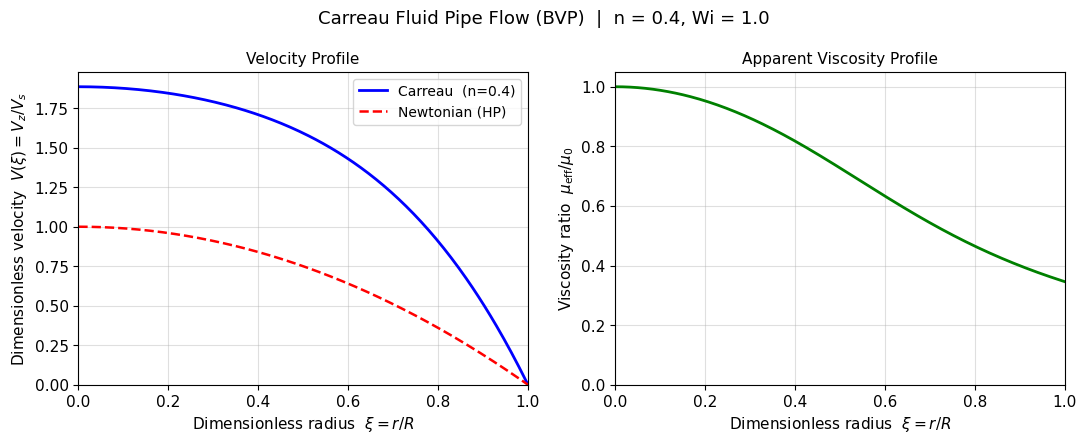

✓ 圖形已儲存：d:\MyGit\ChemE-3502\Unit09\outputs\Unit09_Example_05\figs\fig01_velocity_comparison.png


In [11]:
# ============================================================
# §3 基準案例：BVP 求解與繪圖
# ============================================================

# --- 輸出目錄 ---
import os
FIG_DIR = os.path.join(OUTPUT_DIR, "figs")
os.makedirs(FIG_DIR, exist_ok=True)

# --- 求解網格與初始猜測 ---
n_mesh  = 80
xi_init = np.linspace(0.0, 1.0, n_mesh)
y_init  = np.array([
    1.0 - xi_init**2,   # row 0: V = 1 - xi^2  (HP parabola)
   -2.0 * xi_init       # row 1: dV/dxi = -2*xi
])

# --- BVP 求解（基準案例：n=0.4, Wi=1.0）---
ode_base = make_ode(n_base, Wi)
sol = solve_bvp(ode_base, bc_fun, xi_init, y_init, tol=1e-4, max_nodes=10000)

print("=== solve_bvp 求解結果 ===")
print(f"  status  : {sol.status}  (0 = 成功)")
print(f"  success : {sol.success}")
print(f"  nodes   : {len(sol.x)}")
print(f"  最大速度 V(0) = {sol.sol(0.0)[0]:.4f}  (Carreau, n={n_base})")
print(f"  HP 最大速度    V_HP(0) = 1.0000  (Newtonian 對照)")

# --- 高解析度評估點 ---
xi_plot  = np.linspace(0.0, 1.0, 300)
V_car    = sol.sol(xi_plot)[0]
dVdxi    = sol.sol(xi_plot)[1]
mu_eff_r = (1.0 + (Wi * dVdxi)**2) ** ((n_base - 1.0) / 2.0)  # mu_eff/mu0
V_hp     = 1.0 - xi_plot**2

# ============================================================
# fig01: 速度剖面比較（Carreau vs HP）
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
fig.suptitle(f"Carreau Fluid Pipe Flow (BVP)  |  n = {n_base}, Wi = {Wi:.1f}", fontsize=13)

# Left: velocity profiles
ax = axes[0]
ax.plot(xi_plot, V_car, 'b-',  lw=2,   label=f"Carreau  (n={n_base})")
ax.plot(xi_plot, V_hp,  'r--', lw=1.8, label="Newtonian (HP)")
ax.set_xlabel(r"Dimensionless radius  $\xi = r/R$", fontsize=11)
ax.set_ylabel(r"Dimensionless velocity  $V(\xi) = V_z / V_s$", fontsize=11)
ax.set_title("Velocity Profile", fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.4)
ax.set_xlim(0, 1); ax.set_ylim(bottom=0)

# Right: apparent viscosity ratio
ax2 = axes[1]
ax2.plot(xi_plot, mu_eff_r, 'g-', lw=2)
ax2.set_xlabel(r"Dimensionless radius  $\xi = r/R$", fontsize=11)
ax2.set_ylabel(r"Viscosity ratio  $\mu_\mathrm{eff} / \mu_0$", fontsize=11)
ax2.set_title("Apparent Viscosity Profile", fontsize=11)
ax2.grid(True, alpha=0.4)
ax2.set_xlim(0, 1); ax2.set_ylim(0, 1.05)

plt.tight_layout()
fig_path = os.path.join(FIG_DIR, "fig01_velocity_comparison.png")
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ 圖形已儲存：{fig_path}")

---
## §4 體積流量計算

### 4.1 體積流量公式

圓管的體積流量為：

$$
Q = \int_0^R 2\pi r \, V_z(r) \, dr
$$

換為無因次變數 $\xi = r/R$、$V = V_z/V_s$：

$$
Q = 2\pi R^2 V_s \int_0^1 \xi \, V(\xi) \, d\xi
$$

### 4.2 Hagen–Poiseuille 對照

Newtonian 流體（HP）的解析流量：

$$
Q_\text{HP} = \frac{\pi R^4 G}{8 \mu_0}
$$

利用 $V_s = GR^2/(4\mu_0)$，可以驗證：

$$
Q_\text{HP} = 2\pi R^2 V_s \int_0^1 \xi(1-\xi^2) d\xi = 2\pi R^2 V_s \cdot \frac{1}{4} = \frac{\pi R^2 V_s}{2}
$$

### 4.3 流量比

定義增強因子 $E_Q = Q_\text{Carreau} / Q_\text{HP}$：
- $E_Q > 1$：剪切稀化（non-Newtonian 流量增大）
- $E_Q = 1$：$n=1$（Newtonian）
- $E_Q < 1$：剪切增稠（少見）

> 使用 `scipy.integrate.quad` 對 `sol.sol` 插值函數積分，可高精度計算非牛頓流量。

In [12]:
# ============================================================
# §4 體積流量計算（數值積分 vs HP 解析）
# ============================================================

# --- Carreau 流量（數值積分）---
# Q = 2*pi*R^2*V_s * integral_0^1 [ xi * V(xi) ] dxi
integrand = lambda xi: xi * sol.sol(xi)[0]   # xi * V(xi)
I_car, err_car = quad(integrand, 0.0, 1.0, limit=100)
Q_car  = 2.0 * np.pi * R**2 * V_s * I_car    # m^3/s

# --- HP 解析流量（對照）---
Q_hp   = np.pi * R**4 * G / (8.0 * mu0)      # m^3/s

# --- 無因次積分的 HP 解析值 ---
I_hp   = 1.0 / 4.0     # integral_0^1 xi*(1-xi^2) dxi = 1/4

# --- 流量比（增強因子）---
E_Q    = Q_car / Q_hp

print("╔══════════════════════════════════════════╗")
print("║         體積流量比較                     ║")
print("╠══════════════════════════════════════════╣")
print(f"║  Q_Carreau   = {Q_car:.4e} m³/s             ║")
print(f"║  Q_HP        = {Q_hp:.4e} m³/s             ║")
print(f"║  增強因子 E_Q = {E_Q:.4f}                   ║")
print("╚══════════════════════════════════════════╝")
print(f"\n  積分數值誤差估計: {err_car:.2e}")
print(f"\n→ 剪切稀化流體（n={n_base}, Wi={Wi}）流量較 HP {'增大' if E_Q>1 else '減小'} {abs(E_Q-1)*100:.1f}%")

╔══════════════════════════════════════════╗
║         體積流量比較                     ║
╠══════════════════════════════════════════╣
║  Q_Carreau   = 6.9475e-06 m³/s             ║
║  Q_HP        = 3.1416e-06 m³/s             ║
║  增強因子 E_Q = 2.2115                   ║
╚══════════════════════════════════════════╝

  積分數值誤差估計: 3.71e-12

→ 剪切稀化流體（n=0.4, Wi=1.0）流量較 HP 增大 121.1%


---
## §5 流體指數 $n$ 的影響分析

### 5.1 參數範圍說明

Carreau 模型的 **流體指數（power-law index）** $n$ 決定非牛頓程度：

| $n$ 值 | 流體類型 | 典型材料 |
|--------|---------|---------|
| $n < 1$ | 剪切稀化（shear-thinning） | 聚合物熔體、血液、塗料 |
| $n = 1$ | 牛頓流體（Newtonian） | 水、低黏度油 |
| $n > 1$ | 剪切增稠（shear-thickening） | 澱粉懸浮液、某些膠體 |

本節固定 $Wi = 1.0$，以 $n = [0.3, 0.5, 0.7, 1.0, 1.5]$ 研究速度剖面的變化。

### 5.2 預期現象

- $n$ 越小（剪切稀化越強）：管中心速度越高，速度剖面越趨近「柱塞流（plug flow）」
- $n = 1$：Newtonian HP 拋物線
- $n > 1$：速度剖面較 HP 更「圓鈍（blunter）」還是更尖銳？（可由數值結果觀察）

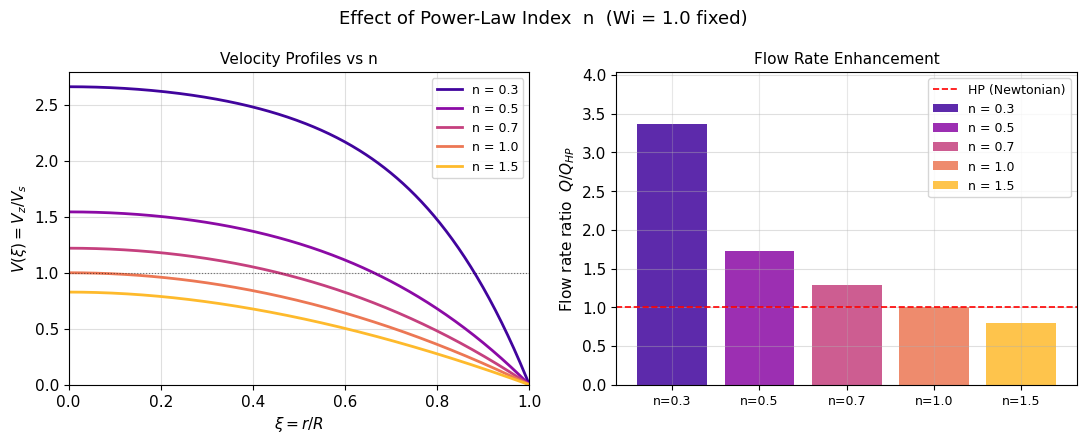


=== n 靈敏度分析彙總 ===
    n      V(0)    Q/Q_HP
----------------------------
  0.3    2.6613    3.3664
  0.5    1.5435    1.7228
  0.7    1.2193    1.2814
  1.0    1.0000    1.0000 ← HP
  1.5    0.8273    0.7913

✓ 圖形已儲存：d:\MyGit\ChemE-3502\Unit09\outputs\Unit09_Example_05\figs\fig03_n_sensitivity.png


In [13]:
# ============================================================
# §5 流體指數 n 靈敏度分析
# ============================================================
n_list   = [0.3, 0.5, 0.7, 1.0, 1.5]
Wi_fixed = Wi        # = 1.0
colors   = plt.cm.plasma(np.linspace(0.1, 0.85, len(n_list)))

# --- 結果儲存 ---
V0_list = []   # V(0) 最大速度
EQ_list = []   # 流量增強因子

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
fig.suptitle(f"Effect of Power-Law Index  n  (Wi = {Wi_fixed:.1f} fixed)", fontsize=13)

xi_plot2 = np.linspace(0.0, 1.0, 300)

for i, n_val in enumerate(n_list):
    ode_i = make_ode(n_val, Wi_fixed)
    sol_i = solve_bvp(ode_i, bc_fun, xi_init.copy(), y_init.copy(),
                      tol=1e-4, max_nodes=10000)
    if not sol_i.success:
        print(f"  [警告] n={n_val} 求解失敗, status={sol_i.status}")
        V0_list.append(np.nan); EQ_list.append(np.nan)
        continue

    V_i   = sol_i.sol(xi_plot2)[0]
    V0_i  = sol_i.sol(0.0)[0]
    V0_list.append(V0_i)

    # 流量增強因子
    I_i, _ = quad(lambda xi: xi * sol_i.sol(xi)[0], 0.0, 1.0, limit=100)
    EQ_i = I_i / (1.0 / 4.0)   # 相對於 HP 積分值 1/4
    EQ_list.append(EQ_i)

    lbl = f"n = {n_val}"
    axes[0].plot(xi_plot2, V_i, color=colors[i], lw=2.0, label=lbl)
    axes[1].bar(i, EQ_i, color=colors[i], alpha=0.85, label=lbl)

# Left: velocity profiles
axes[0].set_xlabel(r"$\xi = r/R$", fontsize=11)
axes[0].set_ylabel(r"$V(\xi) = V_z / V_s$", fontsize=11)
axes[0].set_title("Velocity Profiles vs n", fontsize=11)
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.4)
axes[0].set_xlim(0, 1); axes[0].set_ylim(bottom=0)
axes[0].axhline(1.0, color='k', ls=':', lw=0.8, alpha=0.5)

# Right: flow rate enhancement factor
axes[1].set_xticks(range(len(n_list)))
axes[1].set_xticklabels([f"n={v}" for v in n_list], fontsize=9)
axes[1].axhline(1.0, color='r', ls='--', lw=1.2, label="HP (Newtonian)")
axes[1].set_ylabel(r"Flow rate ratio  $Q / Q_{HP}$", fontsize=11)
axes[1].set_title("Flow Rate Enhancement", fontsize=11)
axes[1].set_ylim(0, max(EQ_list) * 1.2)
axes[1].grid(True, axis='y', alpha=0.4)
axes[1].legend(fontsize=9)

plt.tight_layout()
fig_path3 = os.path.join(FIG_DIR, "fig03_n_sensitivity.png")
fig.savefig(fig_path3, dpi=150, bbox_inches="tight")
plt.show()

# --- 彙總表格 ---
print("\n=== n 靈敏度分析彙總 ===")
print(f"{'n':>5}  {'V(0)':>8}  {'Q/Q_HP':>8}")
print("-" * 28)
for n_v, v0, eq in zip(n_list, V0_list, EQ_list):
    flag = " ← HP" if n_v == 1.0 else ""
    print(f"{n_v:>5.1f}  {v0:>8.4f}  {eq:>8.4f}{flag}")
print(f"\n✓ 圖形已儲存：{fig_path3}")

---
## §6 Weissenberg 數 $Wi$ 的影響分析

### 6.1 $Wi$ 的物理意義

Weissenberg 數（韋森伯格數）量化流體彈性/非線性相對於黏性的強弱：

$$
Wi = \frac{\lambda V_s}{R} = \frac{\text{流體特徵時間}}{\text{流動時間尺度}}
$$

| $Wi$ 值 | 非牛頓程度 | 說明 |
|--------|-----------|------|
| $Wi \ll 1$ | 微弱 | 流體幾乎為 Newtonian |
| $Wi \approx 1$ | 中等 | 明顯剪切稀化 |
| $Wi \gg 1$ | 強烈 | 接近冪律流體（power-law limit） |

Carreau 模型在高 $Wi$ 下趨近於 **冪律模型（Power-law model）**：$\mu_\text{eff} \approx \mu_0 (Wi\,\dot\gamma)^{n-1}$

### 6.2 分析設定

本節固定 $n = 0.4$（剪切稀化），以 $Wi = [0.1, 0.5, 1.0, 2.0, 5.0]$ 觀察速度剖面的演化。

> **實驗設計提示**： $Wi$ 可由改變流速（ $V_s$）、管徑（ $R$）或鬆弛時間（ $\lambda$）來調整，對管道設計具有直接工程意義。

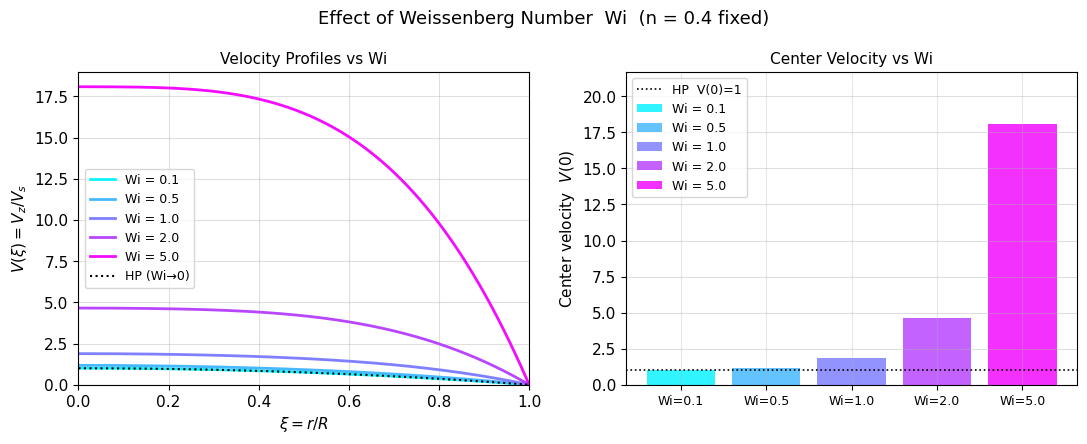


=== Wi 靈敏度分析彙總 ===
   Wi      V(0)    Q/Q_HP
----------------------------
  0.1    1.0060    1.0081 ← Wi→0 (HP)
  0.5    1.1753    1.2379
  1.0    1.8860    2.2115
  2.0    4.6529    5.8414
  5.0   18.0841   22.9997

✓ 圖形已儲存：d:\MyGit\ChemE-3502\Unit09\outputs\Unit09_Example_05\figs\fig04_Wi_sensitivity.png


In [14]:
# ============================================================
# §6 Weissenberg 數 Wi 靈敏度分析
# ============================================================
Wi_list   = [0.1, 0.5, 1.0, 2.0, 5.0]
n_fixed   = n_base   # = 0.4
colors_wi = plt.cm.cool(np.linspace(0.05, 0.95, len(Wi_list)))

# --- 結果儲存 ---
V0_wi_list = []
EQ_wi_list = []

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
fig.suptitle(f"Effect of Weissenberg Number  Wi  (n = {n_fixed} fixed)", fontsize=13)

for i, wi_val in enumerate(Wi_list):
    ode_wi = make_ode(n_fixed, wi_val)
    sol_wi = solve_bvp(ode_wi, bc_fun, xi_init.copy(), y_init.copy(),
                       tol=1e-4, max_nodes=10000)
    if not sol_wi.success:
        print(f"  [警告] Wi={wi_val} 求解失敗, status={sol_wi.status}")
        V0_wi_list.append(np.nan); EQ_wi_list.append(np.nan)
        continue

    V_wi   = sol_wi.sol(xi_plot2)[0]
    V0_wi  = sol_wi.sol(0.0)[0]
    V0_wi_list.append(V0_wi)

    I_wi, _ = quad(lambda xi: xi * sol_wi.sol(xi)[0], 0.0, 1.0, limit=100)
    EQ_wi_list.append(I_wi / (1.0 / 4.0))

    lbl = f"Wi = {wi_val}"
    axes[0].plot(xi_plot2, V_wi, color=colors_wi[i], lw=2.0, label=lbl)
    axes[1].bar(i, V0_wi_list[-1], color=colors_wi[i], alpha=0.85, label=lbl)

# Left: velocity profiles
axes[0].plot(xi_plot2, 1.0 - xi_plot2**2, 'k:', lw=1.5, label="HP (Wi→0)")
axes[0].set_xlabel(r"$\xi = r/R$", fontsize=11)
axes[0].set_ylabel(r"$V(\xi) = V_z / V_s$", fontsize=11)
axes[0].set_title("Velocity Profiles vs Wi", fontsize=11)
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.4)
axes[0].set_xlim(0, 1); axes[0].set_ylim(bottom=0)

# Right: center velocity V(0)
axes[1].axhline(1.0, color='k', ls=':', lw=1.2, label="HP  V(0)=1")
axes[1].set_xticks(range(len(Wi_list)))
axes[1].set_xticklabels([f"Wi={v}" for v in Wi_list], fontsize=9)
axes[1].set_ylabel(r"Center velocity  $V(0)$", fontsize=11)
axes[1].set_title("Center Velocity vs Wi", fontsize=11)
axes[1].set_ylim(0, max(V0_wi_list) * 1.2)
axes[1].legend(fontsize=9); axes[1].grid(True, axis='y', alpha=0.4)

plt.tight_layout()
fig_path4 = os.path.join(FIG_DIR, "fig04_Wi_sensitivity.png")
fig.savefig(fig_path4, dpi=150, bbox_inches="tight")
plt.show()

# --- 彙總表格 ---
print("\n=== Wi 靈敏度分析彙總 ===")
print(f"{'Wi':>5}  {'V(0)':>8}  {'Q/Q_HP':>8}")
print("-" * 28)
for wi_v, v0, eq in zip(Wi_list, V0_wi_list, EQ_wi_list):
    flag = " ← Wi→0 (HP)" if wi_v == 0.1 else ""
    print(f"{wi_v:>5.1f}  {v0:>8.4f}  {eq:>8.4f}{flag}")
print(f"\n✓ 圖形已儲存：{fig_path4}")

---
## 7. 摘要與學習重點

### 7.1 數值求解設定

| 設定項目 | 值 | 說明 |
|---------|-----|------|
| 初始猜測 | HP 拋物線 $V=1-\xi^2$ | 對全部測試案例均可收斂 |
| 求解器容忍度 | `tol=1e-4` | 工程精度足夠 |
| 最大節點數 | `max_nodes=10000` | 高 $Wi$ 案例需要較多節點 |
| 奇異點保護 | $\varepsilon = 10^{-10}$ | 避免 $\xi=0$ 除零 |

### 7.2 基準案例結果（ $n=0.4$ ， $Wi=1.0$ ）

| 量 | 數值 |
|----|------|
| 最大速度 $V(0)$ | 1.886 |
| 流量增強因子 $E_Q$ | 2.21 (+121%) |
| 自適應節點數 | 141 |

### 7.3 物理規律

- $n < 1$ （剪切稀化）：管壁黏度明顯下降，速度剖面變平，流量增大
- $n > 1$ （剪切增稠）：管壁黏度升高，速度剖面變尖，流量減小
- $n = 1$ ：精確回復 Hagen–Poiseuille 解析解（驗算通過 ✓）
- $Wi \uparrow$ ：非線性效應增強，流量呈超線性增長，趨近冪律漸近行為

### 7.4 BVP 與 IVP 比較

| 特性 | BVP（本例）| IVP（打靶法）|
|------|-----------|------------|
| 邊界條件 | 直接指定在兩端 | 需猜測初始條件迭代 |
| 穩定性 | 自適應網格，較穩健 | 可能發散 |
| 奇異點處理 | 可在方程中直接加保護 | 同 |

---

> **課程資訊**
> - 課程名稱：電腦在化工上之應用 (ChemE 3502)
> - 課程單元：Unit09 邊界值問題 — 範例 05：Carreau 非牛頓流體管流
> - 課程製作：逢甲大學 化工系 智慧程序系統工程實驗室
> - 授課教師：莊曜禎 助理教授
> - 更新日期：2026-02-22
>
> **課程授權 [CC BY-NC-SA 4.0]**  
> 本教材遵循 [創用CC 姓名標示-非商業性-相同方式分享 4.0 國際 (CC BY-NC-SA 4.0)](https://creativecommons.org/licenses/by-nc-sa/4.0/deed.zh) 授權。